# Sistema de recomendación de productos ortopédicos de CEMYDI

**Técnica:** recomendación basada principalmente en contenido con similitud de coseno  
**Unidad de análisis:** un producto activo del catálogo  
**Resultado:** lista ordenada de cinco productos similares  
**Semilla:** 42


# 1. Comprensión del negocio

El objetivo es mostrar productos similares en la sección **“También te puede interesar”** de la vista de detalle.


# 2. Comprensión de los datos

In [1]:
from pathlib import Path
from datetime import datetime
import json
import math
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TOP_K = 5
BATCH_NAME = "CEMYDI_DEMO_2024_2026_V1"

VENTANAS_VALIDACION = [
    pd.Period("2026-04", freq="M"),
    pd.Period("2026-05", freq="M"),
    pd.Period("2026-06", freq="M"),
]
VENTANA_PRUEBA = pd.Period("2026-07", freq="M")

directorio_actual = Path.cwd()
raiz_proyecto = (
    directorio_actual.parent
    if directorio_actual.name == "06_Notebooks"
    else directorio_actual
)

carpeta_modelos = raiz_proyecto / "07_Modelos" / "recomendacion"
carpeta_modelos.mkdir(parents=True, exist_ok=True)

print("Configuración lista.")
print("Raíz del proyecto:", raiz_proyecto)


Configuración lista.
Raíz del proyecto: C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM


## 2.1 Carga de los datasets

In [2]:
rutas_productos = [
    directorio_actual / "dataset_recomendacion_productos.csv",
    raiz_proyecto / "05_Datasets" / "dataset_recomendacion_productos.csv",
    Path("/content/dataset_recomendacion_productos.csv"),
]

rutas_interacciones = [
    directorio_actual / "dataset_evaluacion_recomendacion.csv",
    raiz_proyecto / "05_Datasets" / "dataset_evaluacion_recomendacion.csv",
    Path("/content/dataset_evaluacion_recomendacion.csv"),
]

ruta_productos = next((ruta for ruta in rutas_productos if ruta.exists()), None)
ruta_interacciones = next((ruta for ruta in rutas_interacciones if ruta.exists()), None)

if ruta_productos is None or ruta_interacciones is None:
    raise FileNotFoundError(
        "No se encontraron dataset_recomendacion_productos.csv "
        "y dataset_evaluacion_recomendacion.csv."
    )

productos = pd.read_csv(ruta_productos)
interacciones = (
    pd.read_csv(ruta_interacciones, parse_dates=["occurred_at"])
    .sort_values("occurred_at")
    .reset_index(drop=True)
)

print("Dataset de productos:", productos.shape)
print("Dataset de interacciones:", interacciones.shape)
display(productos.head())
display(interacciones.head())


Dataset de productos: (40, 9)
Dataset de interacciones: (18738, 4)


,product_id,product_name,classification,acquisition_type,price,stock,requires_prescription,views,searches
0,179,Silla de ruedas estándar,Movilidad,MIXTO,"6,164.0700",29,False,218,53
1,180,Silla de ruedas reclinable,Movilidad,MIXTO,"10,622.6300",61,False,336,106
2,181,Silla de ruedas bariátrica,Movilidad,RENTA,"18,396.5000",13,False,337,99
3,182,Andadera plegable aluminio,Apoyo para caminar,MIXTO,"2,781.5400",20,False,205,57
4,183,Bastón de cuatro apoyos,Apoyo para caminar,VENTA,"1,318.1900",53,False,336,98


,customer_id,product_id,interaction_type,occurred_at
0,1392,195,SEARCH,2024-01-20 05:56:51
1,1294,204,VIEW,2024-01-20 11:52:46
2,1294,212,VIEW,2024-02-06 14:08:02
3,1552,185,ADD_TO_CART,2024-02-08 12:01:00
4,1262,214,VIEW,2024-02-08 15:02:41


## 2.2 Dimensiones y primeras filas

Se revisan por separado el catálogo de productos y el historial de interacciones.

In [3]:
dimensiones = pd.DataFrame({
    "Dataset": [
        "Productos para recomendación",
        "Interacciones para evaluación",
    ],
    "Filas": [
        productos.shape[0],
        interacciones.shape[0],
    ],
    "Columnas": [
        productos.shape[1],
        interacciones.shape[1],
    ],
    "Unidad de análisis": [
        "Un producto activo",
        "Una interacción cliente-producto",
    ],
})

display(dimensiones)

print("Primeros cinco productos")
display(productos.head())

print("Primeras cinco interacciones")
display(interacciones.head())

,Dataset,Filas,Columnas,Unidad de análisis
0,Productos para recomendación,40,9,Un producto activo
1,Interacciones para evaluación,18738,4,Una interacción cliente-producto


Primeros cinco productos


,product_id,product_name,classification,acquisition_type,price,stock,requires_prescription,views,searches
0,179,Silla de ruedas estándar,Movilidad,MIXTO,"6,164.0700",29,False,218,53
1,180,Silla de ruedas reclinable,Movilidad,MIXTO,"10,622.6300",61,False,336,106
2,181,Silla de ruedas bariátrica,Movilidad,RENTA,"18,396.5000",13,False,337,99
3,182,Andadera plegable aluminio,Apoyo para caminar,MIXTO,"2,781.5400",20,False,205,57
4,183,Bastón de cuatro apoyos,Apoyo para caminar,VENTA,"1,318.1900",53,False,336,98


Primeras cinco interacciones


,customer_id,product_id,interaction_type,occurred_at
0,1392,195,SEARCH,2024-01-20 05:56:51
1,1294,204,VIEW,2024-01-20 11:52:46
2,1294,212,VIEW,2024-02-06 14:08:02
3,1552,185,ADD_TO_CART,2024-02-08 12:01:00
4,1262,214,VIEW,2024-02-08 15:02:41


## 2.3 Información general y tipos de datos

In [4]:
print("Información del dataset de productos")
productos.info()

print("\nInformación del dataset de interacciones")
interacciones.info()

Información del dataset de productos
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             40 non-null     int64  
 1   product_name           40 non-null     str    
 2   classification         40 non-null     str    
 3   acquisition_type       40 non-null     str    
 4   price                  40 non-null     float64
 5   stock                  40 non-null     int64  
 6   requires_prescription  40 non-null     bool   
 7   views                  40 non-null     int64  
 8   searches               40 non-null     int64  
dtypes: bool(1), float64(1), int64(4), str(3)
memory usage: 2.7 KB

Información del dataset de interacciones
<class 'pandas.DataFrame'>
RangeIndex: 18738 entries, 0 to 18737
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -

## 2.4 Estadísticas descriptivas

In [5]:
print("Estadísticas del catálogo de productos")
display(productos.describe(include="all").T)

print("Estadísticas del historial de interacciones")
display(interacciones.describe(include="all").T)

Estadísticas del catálogo de productos


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,40.0000,NaN,NaN,NaN,198.5000,11.6905,179.0000,188.7500,198.5000,208.2500,218.0000
product_name,40,40,Silla de ruedas estándar,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classification,40,9,Oxigenoterapia,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_type,40,3,VENTA,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,40.0000,NaN,NaN,NaN,"12,206.8950","15,067.9616",954.5200,"1,914.6950","4,709.8650","16,330.4675","52,279.9200"
stock,40.0000,NaN,NaN,NaN,33.8250,13.7764,12.0000,20.7500,33.0000,46.0000,61.0000
requires_prescription,40,2,False,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40.0000,NaN,NaN,NaN,297.5250,83.4238,151.0000,235.5000,287.5000,375.5000,479.0000
searches,40.0000,NaN,NaN,NaN,85.1750,23.4169,39.0000,65.0000,85.0000,101.5000,130.0000


Estadísticas del historial de interacciones


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,"18,738.0000",NaN,NaN,NaN,"1,455.8256","1,257.0000","1,354.0000","1,455.0000","1,555.0000","1,656.0000",115.6700
product_id,"18,738.0000",NaN,NaN,NaN,198.6336,179.0000,189.0000,199.0000,208.0000,218.0000,11.3474
interaction_type,18738,5,VIEW,11901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occurred_at,18738,NaN,NaN,NaN,2025-11-17 20:07:01.336962,2024-01-20 05:56:51,2025-08-03 02:31:52.750000,2026-01-03 04:22:08.500000,2026-04-10 07:53:20.750000,2026-07-31 15:02:00,NaN


## 2.5 Valores nulos

In [6]:
nulos_productos = pd.DataFrame({
    "Columna": productos.columns,
    "Valores nulos": productos.isnull().sum().values,
    "Porcentaje": (
        productos.isnull().mean().values * 100
    ),
})

nulos_interacciones = pd.DataFrame({
    "Columna": interacciones.columns,
    "Valores nulos": interacciones.isnull().sum().values,
    "Porcentaje": (
        interacciones.isnull().mean().values * 100
    ),
})

print("Valores nulos en productos")
display(nulos_productos.round(2))

print("Valores nulos en interacciones")
display(nulos_interacciones.round(2))

Valores nulos en productos


,Columna,Valores nulos,Porcentaje
0,product_id,0,0.0000
1,product_name,0,0.0000
2,classification,0,0.0000
3,acquisition_type,0,0.0000
4,price,0,0.0000
5,stock,0,0.0000
6,requires_prescription,0,0.0000
7,views,0,0.0000
8,searches,0,0.0000


Valores nulos en interacciones


,Columna,Valores nulos,Porcentaje
0,customer_id,0,0.0000
1,product_id,0,0.0000
2,interaction_type,0,0.0000
3,occurred_at,0,0.0000


## 2.6 Duplicados y validaciones de calidad

In [7]:
TIPOS_INTERACCION_VALIDOS = {
    "VIEW",
    "SEARCH",
    "ADD_TO_CART",
    "FAVORITE",
    "SHARE",
}

ids_catalogo = set(productos["product_id"].astype(int))
ids_interacciones = set(interacciones["product_id"].astype(int))

fecha_inicio = pd.Timestamp("2024-01-01")
fecha_fin = pd.Timestamp("2026-07-31 23:59:59")

reporte_calidad = pd.DataFrame({
    "Revisión": [
        "Duplicados exactos en productos",
        "Identificadores de producto repetidos",
        "Duplicados exactos en interacciones",
        "Productos de interacción ausentes del catálogo",
        "Precios no positivos",
        "Stocks negativos",
        "Tipos de interacción inválidos",
        "Fechas inválidas",
        "Interacciones fuera del periodo",
    ],
    "Resultado": [
        int(productos.duplicated().sum()),
        int(productos["product_id"].duplicated().sum()),
        int(interacciones.duplicated().sum()),
        int(len(ids_interacciones - ids_catalogo)),
        int((productos["price"] <= 0).sum()),
        int((productos["stock"] < 0).sum()),
        int(
            (~interacciones["interaction_type"].isin(
                TIPOS_INTERACCION_VALIDOS
            )).sum()
        ),
        int(interacciones["occurred_at"].isna().sum()),
        int(
            (
                (interacciones["occurred_at"] < fecha_inicio)
                | (interacciones["occurred_at"] > fecha_fin)
            ).sum()
        ),
    ],
})

reporte_calidad

,Revisión,Resultado
0,Duplicados exactos en productos,0
1,Identificadores de producto repetidos,0
2,Duplicados exactos en interacciones,0
3,Productos de interacción ausentes del catálogo,0
4,Precios no positivos,0
5,Stocks negativos,0
6,Tipos de interacción inválidos,0
7,Fechas inválidas,0
8,Interacciones fuera del periodo,0


## 2.7 Variabilidad de los atributos

In [8]:
variabilidad_productos = pd.DataFrame({
    "Columna": productos.columns,
    "Valores únicos": [
        productos[columna].nunique(dropna=False)
        for columna in productos.columns
    ],
})

variabilidad_interacciones = pd.DataFrame({
    "Columna": interacciones.columns,
    "Valores únicos": [
        interacciones[columna].nunique(dropna=False)
        for columna in interacciones.columns
    ],
})

print("Variabilidad en productos")
display(variabilidad_productos)

print("Variabilidad en interacciones")
display(variabilidad_interacciones)

Variabilidad en productos


,Columna,Valores únicos
0,product_id,40
1,product_name,40
2,classification,9
3,acquisition_type,3
4,price,40
5,stock,26
6,requires_prescription,2
7,views,37
8,searches,31


Variabilidad en interacciones


,Columna,Valores únicos
0,customer_id,400
1,product_id,40
2,interaction_type,5
3,occurred_at,18733


## 2.8 Distribución de las variables numéricas

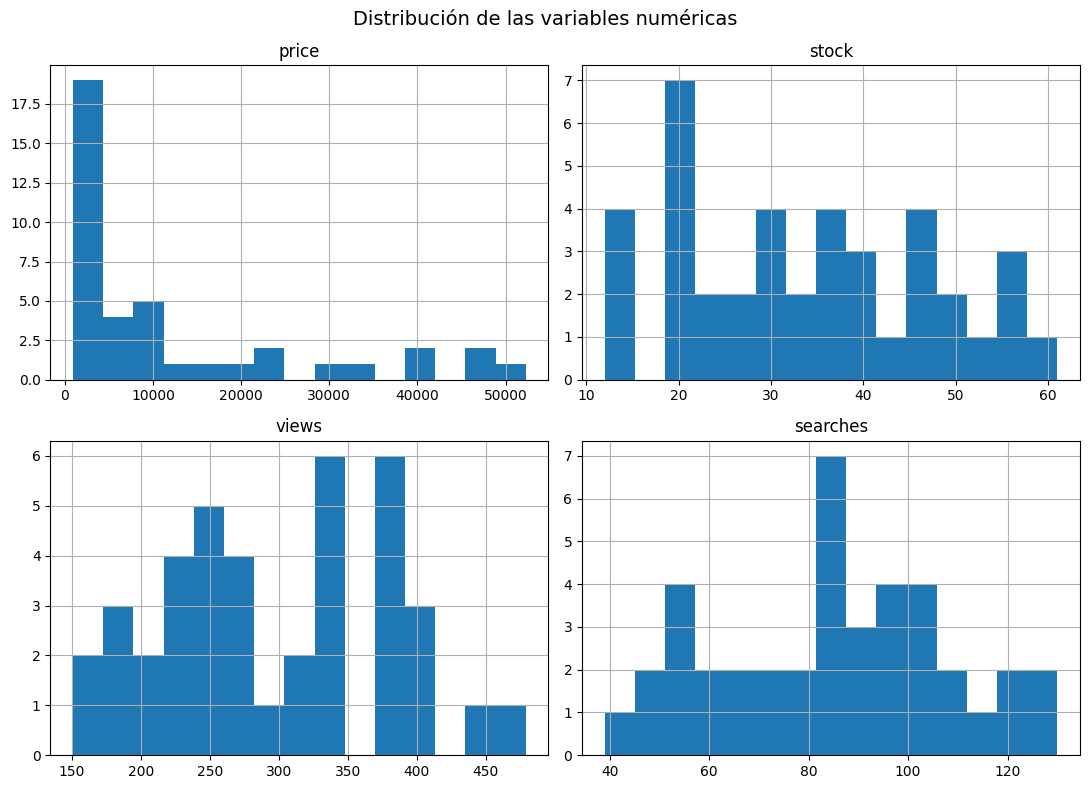

In [9]:
variables_numericas = [
    "price",
    "stock",
    "views",
    "searches",
]

productos[variables_numericas].hist(
    figsize=(11, 8),
    bins=15,
)
plt.suptitle(
    "Distribución de las variables numéricas",
    fontsize=14,
)
plt.tight_layout()
plt.show()

Las variables se encuentran en escalas distintas. Por ello, en la preparación se aplica `log1p` y posteriormente `StandardScaler`.

## 2.9 Boxplots de las variables numéricas

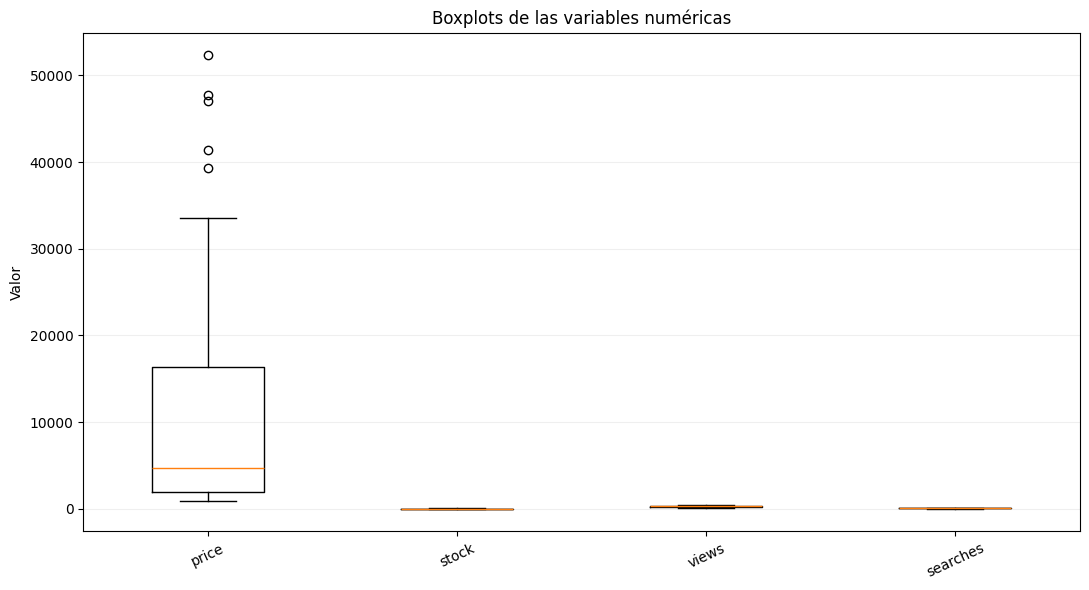

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot(
    [productos[columna] for columna in variables_numericas],
    tick_labels=variables_numericas,
)

ax.set_title("Boxplots de las variables numéricas")
ax.set_ylabel("Valor")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

Los valores altos se conservan porque corresponden a diferencias reales entre productos y señales de interacción del catálogo sintético.

## 2.10 Distribución de productos por clasificación

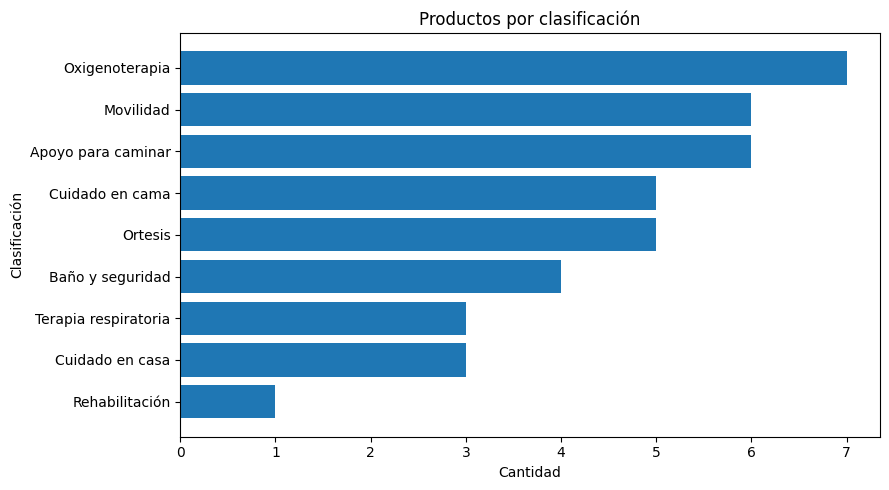

In [11]:
productos_por_clasificacion = (
    productos["classification"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 5))
plt.barh(
    productos_por_clasificacion.index,
    productos_por_clasificacion.values,
)
plt.title("Productos por clasificación")
plt.xlabel("Cantidad")
plt.ylabel("Clasificación")
plt.tight_layout()
plt.show()


La clasificación representa la familia funcional del producto y es una de las variables principales del recomendador.

## 2.11 Distribución de los tipos de interacción

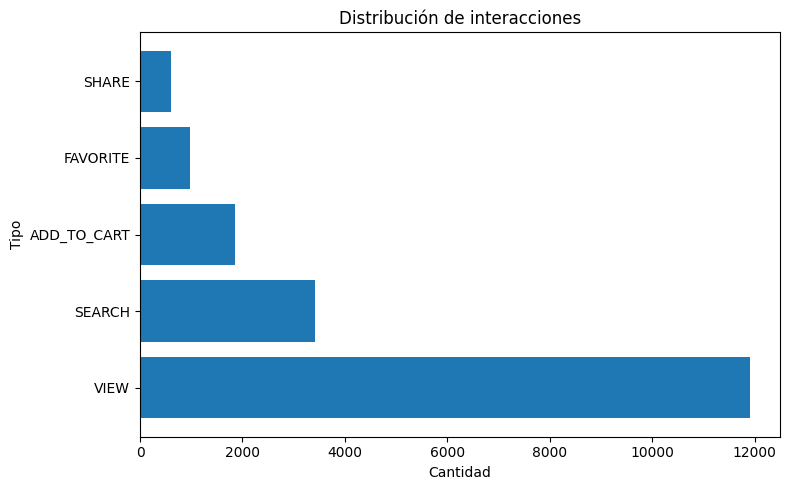

,Cantidad,Porcentaje
interaction_type,,
VIEW,11901,63.5100
SEARCH,3407,18.1800
ADD_TO_CART,1853,9.8900
FAVORITE,979,5.2200
SHARE,598,3.1900


In [12]:
orden_interacciones = [
    "VIEW",
    "SEARCH",
    "ADD_TO_CART",
    "FAVORITE",
    "SHARE",
]

interacciones_por_tipo = (
    interacciones["interaction_type"]
    .value_counts()
    .reindex(orden_interacciones, fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.barh(
    interacciones_por_tipo.index,
    interacciones_por_tipo.values,
)
plt.title("Distribución de interacciones")
plt.xlabel("Cantidad")
plt.ylabel("Tipo")
plt.tight_layout()
plt.show()

tabla_interacciones = interacciones_por_tipo.rename("Cantidad").to_frame()
tabla_interacciones["Porcentaje"] = (
    tabla_interacciones["Cantidad"]
    / tabla_interacciones["Cantidad"].sum()
    * 100
)

tabla_interacciones.round(2)


Las vistas son la interacción más frecuente. El modelo utiliza directamente las vistas y búsquedas agregadas por producto.

# 3. Preparación de los datos

In [13]:
COLUMNAS_CATEGORICAS = [
    "classification",
    "acquisition_type",
]

COLUMNAS_NUMERICAS = [
    "price",
    "stock",
    "views",
    "searches",
]

COLUMNA_BINARIA = "requires_prescription"

CONFIGURACIONES = [
    {
        "Configuración": "Balanceada con comportamiento",
        "usa_comportamiento": True,
        "pesos": {
            "categoricas": 1.0,
            "numericas": 1.0,
            "receta": 1.0,
        },
    },
    {
        "Configuración": "Énfasis en contenido",
        "usa_comportamiento": True,
        "pesos": {
            "categoricas": 3.0,
            "numericas": 0.3,
            "receta": 1.0,
        },
    },
    {
        "Configuración": "Solo atributos de catálogo",
        "usa_comportamiento": False,
        "pesos": {
            "categoricas": 3.0,
            "numericas": 0.3,
            "receta": 1.0,
        },
    },
]

def ajustar_transformadores(
    dataframe: pd.DataFrame,
    pesos: dict,
):
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
    scaler = StandardScaler()

    bloque_categorico = encoder.fit_transform(
        dataframe[COLUMNAS_CATEGORICAS]
    )

    bloque_numerico = scaler.fit_transform(
        np.log1p(dataframe[COLUMNAS_NUMERICAS].astype(float))
    )

    bloque_receta = (
        dataframe[[COLUMNA_BINARIA]]
        .astype(float)
        .to_numpy()
    )

    matriz = np.hstack([
        bloque_categorico * pesos["categoricas"],
        bloque_numerico * pesos["numericas"],
        bloque_receta * pesos["receta"],
    ])

    return encoder, scaler, matriz


def transformar_productos(
    dataframe: pd.DataFrame,
    encoder: OneHotEncoder,
    scaler: StandardScaler,
    pesos: dict,
) -> np.ndarray:
    bloque_categorico = encoder.transform(
        dataframe[COLUMNAS_CATEGORICAS]
    )

    bloque_numerico = scaler.transform(
        np.log1p(dataframe[COLUMNAS_NUMERICAS].astype(float))
    )

    bloque_receta = (
        dataframe[[COLUMNA_BINARIA]]
        .astype(float)
        .to_numpy()
    )

    return np.hstack([
        bloque_categorico * pesos["categoricas"],
        bloque_numerico * pesos["numericas"],
        bloque_receta * pesos["receta"],
    ])


Las variables categóricas se convierten con OneHotEncoder. Las variables numéricas reciben log1p y StandardScaler.

# 4. Modelado

In [14]:
IDS_PRODUCTOS = productos["product_id"].astype(int).tolist()

ID_A_INDICE = {
    product_id: indice
    for indice, product_id in enumerate(IDS_PRODUCTOS)
}

NOMBRE_POR_ID = (
    productos
    .set_index("product_id")["product_name"]
    .to_dict()
)

CLASIFICACION_POR_ID = (
    productos
    .set_index("product_id")["classification"]
    .to_dict()
)


def construir_catalogo_para_corte(
    interacciones_entrenamiento: pd.DataFrame,
    usar_comportamiento: bool,
) -> pd.DataFrame:
    catalogo = productos.copy()

    if usar_comportamiento:
        conteos = interacciones_entrenamiento.pivot_table(
            index="product_id",
            columns="interaction_type",
            values="customer_id",
            aggfunc="count",
            fill_value=0,
        )

        catalogo["views"] = (
            catalogo["product_id"]
            .map(conteos.get("VIEW", pd.Series(dtype=float)))
            .fillna(0)
            .astype(int)
        )

        catalogo["searches"] = (
            catalogo["product_id"]
            .map(conteos.get("SEARCH", pd.Series(dtype=float)))
            .fillna(0)
            .astype(int)
        )
    else:
        catalogo["views"] = 0
        catalogo["searches"] = 0

    return catalogo


def construir_casos(
    entrenamiento: pd.DataFrame,
    periodo_objetivo: pd.DataFrame,
) -> pd.DataFrame:
    casos = []

    clientes_comunes = sorted(
        set(entrenamiento["customer_id"])
        & set(periodo_objetivo["customer_id"])
    )

    for customer_id in clientes_comunes:
        historial_previo = (
            entrenamiento[
                entrenamiento["customer_id"] == customer_id
            ]
            .sort_values("occurred_at")
        )

        historial_objetivo = (
            periodo_objetivo[
                periodo_objetivo["customer_id"] == customer_id
            ]
            .sort_values("occurred_at")
        )

        producto_origen = int(historial_previo.iloc[-1]["product_id"])
        producto_objetivo = None

        for product_id in historial_objetivo["product_id"].astype(int):
            if product_id != producto_origen:
                producto_objetivo = int(product_id)
                break

        if producto_objetivo is not None:
            casos.append({
                "customer_id": int(customer_id),
                "source_product_id": producto_origen,
                "target_product_id": producto_objetivo,
            })

    return pd.DataFrame(casos)


def construir_rankings(
    matriz_similitud: np.ndarray,
    k: int,
) -> dict:
    rankings = {}

    for product_id in IDS_PRODUCTOS:
        indice = ID_A_INDICE[product_id]
        orden = np.argsort(-matriz_similitud[indice])

        rankings[product_id] = [
            IDS_PRODUCTOS[posicion]
            for posicion in orden
            if IDS_PRODUCTOS[posicion] != product_id
        ][:k]

    return rankings


def evaluar_rankings(
    rankings: dict,
    matriz_similitud: np.ndarray,
    casos: pd.DataFrame,
    k: int,
) -> dict:
    hits = []
    reciprocal_ranks = []
    ndcg = []

    for _, caso in casos.iterrows():
        origen = int(caso["source_product_id"])
        objetivo = int(caso["target_product_id"])
        lista = rankings.get(origen, [])[:k]

        if objetivo in lista:
            posicion = lista.index(objetivo) + 1
            hits.append(1)
            reciprocal_ranks.append(1 / posicion)
            ndcg.append(1 / np.log2(posicion + 1))
        else:
            hits.append(0)
            reciprocal_ranks.append(0)
            ndcg.append(0)

    recomendados_unicos = {
        product_id
        for lista in rankings.values()
        for product_id in lista[:k]
    }

    diversidades = []

    for lista in rankings.values():
        indices = [
            ID_A_INDICE[product_id]
            for product_id in lista[:k]
        ]

        if len(indices) > 1:
            bloque = matriz_similitud[np.ix_(indices, indices)]
            valores = bloque[np.triu_indices(len(indices), k=1)]
            diversidades.append(float(np.mean(1 - valores)))

    return {
        f"HitRate@{k}": float(np.mean(hits)),
        f"MRR@{k}": float(np.mean(reciprocal_ranks)),
        f"NDCG@{k}": float(np.mean(ndcg)),
        "Cobertura": len(recomendados_unicos) / len(IDS_PRODUCTOS),
        "Diversidad": float(np.mean(diversidades)),
        "Casos": int(len(casos)),
    }


## 4.1 Comparación de configuraciones

In [15]:
resultados_ventanas = []

for ventana in VENTANAS_VALIDACION:
    inicio = ventana.start_time
    fin = ventana.end_time

    entrenamiento = interacciones[
        interacciones["occurred_at"] < inicio
    ].copy()

    objetivo = interacciones[
        (interacciones["occurred_at"] >= inicio)
        & (interacciones["occurred_at"] <= fin)
    ].copy()

    casos = construir_casos(entrenamiento, objetivo)

    for configuracion in CONFIGURACIONES:
        catalogo_ventana = construir_catalogo_para_corte(
            entrenamiento,
            configuracion["usa_comportamiento"],
        )

        encoder, scaler, matriz = ajustar_transformadores(
            catalogo_ventana,
            configuracion["pesos"],
        )

        matriz_similitud = cosine_similarity(matriz)
        rankings = construir_rankings(matriz_similitud, TOP_K)

        metricas = evaluar_rankings(
            rankings,
            matriz_similitud,
            casos,
            TOP_K,
        )

        resultados_ventanas.append({
            "Ventana": str(ventana),
            "Configuración": configuracion["Configuración"],
            "Peso categórico": configuracion["pesos"]["categoricas"],
            "Peso numérico": configuracion["pesos"]["numericas"],
            "Peso receta": configuracion["pesos"]["receta"],
            **metricas,
        })

tabla_ventanas = pd.DataFrame(resultados_ventanas)
tabla_ventanas.round(4)


,Ventana,Configuración,Peso categórico,Peso numérico,Peso receta,HitRate@5,MRR@5,NDCG@5,Cobertura,Diversidad,Casos
0,2026-04,Balanceada con comportamiento,1.0000,1.0000,1.0000,0.1715,0.0883,0.1090,1.0000,0.4576,309
1,2026-04,Énfasis en contenido,3.0000,0.3000,1.0000,0.2265,0.1117,0.1400,1.0000,0.4711,309
2,2026-04,Solo atributos de catálogo,3.0000,0.3000,1.0000,0.2136,0.1057,0.1321,1.0000,0.4674,309
3,2026-05,Balanceada con comportamiento,1.0000,1.0000,1.0000,0.1596,0.0993,0.1143,1.0000,0.4554,307
4,2026-05,Énfasis en contenido,3.0000,0.3000,1.0000,0.2182,0.1122,0.1384,1.0000,0.4715,307
5,2026-05,Solo atributos de catálogo,3.0000,0.3000,1.0000,0.2150,0.1116,0.1371,1.0000,0.4674,307
6,2026-06,Balanceada con comportamiento,1.0000,1.0000,1.0000,0.1423,0.0768,0.0928,1.0000,0.4498,274
7,2026-06,Énfasis en contenido,3.0000,0.3000,1.0000,0.1898,0.0985,0.1210,1.0000,0.4701,274
8,2026-06,Solo atributos de catálogo,3.0000,0.3000,1.0000,0.1934,0.0996,0.1227,1.0000,0.4674,274


In [16]:
metricas_promedio_validacion = (
    tabla_ventanas
    .groupby(
        [
            "Configuración",
            "Peso categórico",
            "Peso numérico",
            "Peso receta",
        ],
        as_index=False,
    )
    .agg({
        "HitRate@5": "mean",
        "MRR@5": "mean",
        "NDCG@5": "mean",
        "Cobertura": "mean",
        "Diversidad": "mean",
        "Casos": "sum",
    })
    .sort_values(
        ["HitRate@5", "MRR@5"],
        ascending=False,
    )
    .reset_index(drop=True)
)

CONFIGURACION_SELECCIONADA = (
    metricas_promedio_validacion.iloc[0]["Configuración"]
)

configuracion_final = next(
    configuracion
    for configuracion in CONFIGURACIONES
    if configuracion["Configuración"] == CONFIGURACION_SELECCIONADA
)

PESOS_FINALES = configuracion_final["pesos"]

display(metricas_promedio_validacion.round(4))
print("Configuración seleccionada:", CONFIGURACION_SELECCIONADA)
print("Pesos finales:", PESOS_FINALES)


,Configuración,Peso categórico,Peso numérico,Peso receta,HitRate@5,MRR@5,NDCG@5,Cobertura,Diversidad,Casos
0,Énfasis en contenido,3.0000,0.3000,1.0000,0.2115,0.1074,0.1331,1.0000,0.4709,890
1,Solo atributos de catálogo,3.0000,0.3000,1.0000,0.2073,0.1056,0.1306,1.0000,0.4674,890
2,Balanceada con comportamiento,1.0000,1.0000,1.0000,0.1578,0.0882,0.1054,1.0000,0.4543,890


Configuración seleccionada: Énfasis en contenido
Pesos finales: {'categoricas': 3.0, 'numericas': 0.3, 'receta': 1.0}


La configuración se selecciona con abril, mayo y junio. Julio se conserva para la prueba final.

# 5. Evaluación

In [17]:
inicio_prueba = VENTANA_PRUEBA.start_time
fin_prueba = VENTANA_PRUEBA.end_time

interacciones_train_final = interacciones[
    interacciones["occurred_at"] < inicio_prueba
].copy()

interacciones_test_final = interacciones[
    (interacciones["occurred_at"] >= inicio_prueba)
    & (interacciones["occurred_at"] <= fin_prueba)
].copy()

casos_prueba = construir_casos(
    interacciones_train_final,
    interacciones_test_final,
)

catalogo_prueba = construir_catalogo_para_corte(
    interacciones_train_final,
    configuracion_final["usa_comportamiento"],
)

encoder_prueba, scaler_prueba, matriz_prueba = ajustar_transformadores(
    catalogo_prueba,
    PESOS_FINALES,
)

similitud_prueba = cosine_similarity(matriz_prueba)
rankings_prueba = construir_rankings(similitud_prueba, TOP_K)

metricas_prueba = evaluar_rankings(
    rankings_prueba,
    similitud_prueba,
    casos_prueba,
    TOP_K,
)

resumen_prueba = pd.DataFrame({
    "Indicador": [
        "Interacciones de entrenamiento",
        "Interacciones de prueba",
        "Casos evaluables",
        "Productos",
        "Dimensiones de características",
        "Dimensiones de similitud",
    ],
    "Resultado": [
        len(interacciones_train_final),
        len(interacciones_test_final),
        len(casos_prueba),
        len(productos),
        str(matriz_prueba.shape),
        str(similitud_prueba.shape),
    ],
})

resumen_prueba


,Indicador,Resultado
0,Interacciones de entrenamiento,18324
1,Interacciones de prueba,414
2,Casos evaluables,116
3,Productos,40
4,Dimensiones de características,"(40, 17)"
5,Dimensiones de similitud,"(40, 40)"


## 5.1 Comparación con líneas base

In [18]:
popularidad_train = (
    interacciones_train_final
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

ranking_popularidad = popularidad_train.index.astype(int).tolist()

rankings_popularidad_global = {
    product_id: [
        candidato
        for candidato in ranking_popularidad
        if candidato != product_id
    ][:TOP_K]
    for product_id in IDS_PRODUCTOS
}

rankings_popularidad_clase = {}

for product_id in IDS_PRODUCTOS:
    clasificacion = CLASIFICACION_POR_ID[product_id]

    misma_clase = [
        candidato
        for candidato in ranking_popularidad
        if candidato != product_id
        and CLASIFICACION_POR_ID[candidato] == clasificacion
    ]

    otras_clases = [
        candidato
        for candidato in ranking_popularidad
        if candidato != product_id
        and candidato not in misma_clase
    ]

    rankings_popularidad_clase[product_id] = (
        misma_clase + otras_clases
    )[:TOP_K]

metricas_popularidad_global = evaluar_rankings(
    rankings_popularidad_global,
    similitud_prueba,
    casos_prueba,
    TOP_K,
)

metricas_popularidad_clase = evaluar_rankings(
    rankings_popularidad_clase,
    similitud_prueba,
    casos_prueba,
    TOP_K,
)

comparacion_prueba_final = pd.DataFrame([
    {
        "Método": "Popularidad global",
        **metricas_popularidad_global,
    },
    {
        "Método": "Popularidad por clasificación",
        **metricas_popularidad_clase,
    },
    {
        "Método": "Contenido + similitud de coseno",
        **metricas_prueba,
    },
])

comparacion_prueba_final.round(4)


,Método,HitRate@5,MRR@5,NDCG@5,Cobertura,Diversidad,Casos
0,Popularidad global,0.2069,0.0935,0.1215,0.1500,0.7821,116
1,Popularidad por clasificación,0.3362,0.1838,0.2210,0.9500,0.4907,116
2,Contenido + similitud de coseno,0.2759,0.1474,0.1794,1.0000,0.4714,116


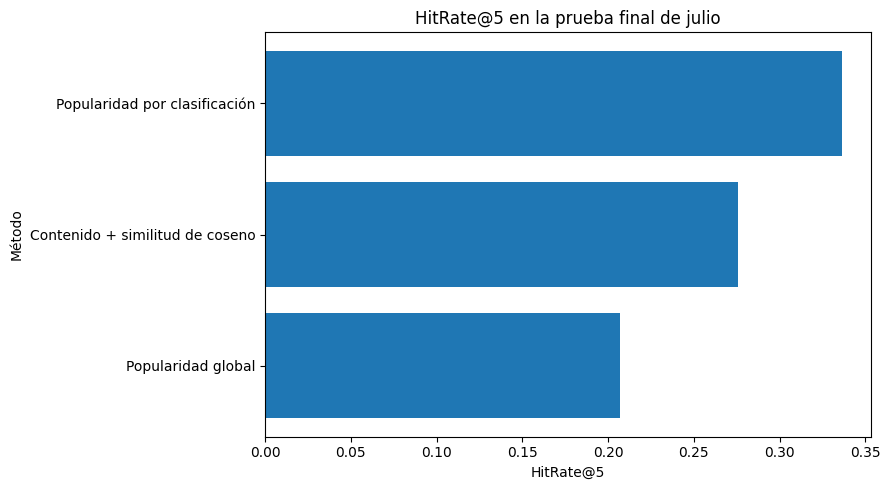

In [19]:
datos_hit = (
    comparacion_prueba_final[
        ["Método", "HitRate@5"]
    ]
    .sort_values("HitRate@5")
)

plt.figure(figsize=(9, 5))
plt.barh(
    datos_hit["Método"],
    datos_hit["HitRate@5"],
)
plt.title("HitRate@5 en la prueba final de julio")
plt.xlabel("HitRate@5")
plt.ylabel("Método")
plt.tight_layout()
plt.show()


El recomendador supera la popularidad global y alcanza cobertura completa, pero no supera la popularidad por clasificación.

## 5.2 Resultado según la clasificación

In [20]:
casos_detalle = casos_prueba.copy()

casos_detalle["same_classification"] = [
    (
        CLASIFICACION_POR_ID[int(origen)]
        == CLASIFICACION_POR_ID[int(objetivo)]
    )
    for origen, objetivo in zip(
        casos_detalle["source_product_id"],
        casos_detalle["target_product_id"],
    )
]

casos_detalle["hit_model"] = [
    int(int(objetivo) in rankings_prueba[int(origen)])
    for origen, objetivo in zip(
        casos_detalle["source_product_id"],
        casos_detalle["target_product_id"],
    )
]

resumen_clasificacion = (
    casos_detalle
    .groupby("same_classification")
    .agg(
        casos=("customer_id", "count"),
        hit_rate=("hit_model", "mean"),
    )
    .rename(index={
        True: "Misma clasificación",
        False: "Clasificación diferente",
    })
    .reset_index()
)

resumen_clasificacion.round(4)


,same_classification,casos,hit_rate
0,Clasificación diferente,81,0.1235
1,Misma clasificación,35,0.6286


El modelo funciona mejor cuando el producto futuro pertenece a la misma clasificación que el producto de origen.

## 5.3 Cinco casos acertados y cinco no acertados

In [21]:
def posicion_acierto(
    origen: int,
    objetivo: int,
):
    lista = rankings_prueba[origen]
    return lista.index(objetivo) + 1 if objetivo in lista else None


casos_detalle["source_name"] = (
    casos_detalle["source_product_id"].map(NOMBRE_POR_ID)
)
casos_detalle["target_name"] = (
    casos_detalle["target_product_id"].map(NOMBRE_POR_ID)
)
casos_detalle["source_classification"] = (
    casos_detalle["source_product_id"].map(CLASIFICACION_POR_ID)
)
casos_detalle["target_classification"] = (
    casos_detalle["target_product_id"].map(CLASIFICACION_POR_ID)
)

casos_detalle["position"] = [
    posicion_acierto(int(origen), int(objetivo))
    for origen, objetivo in zip(
        casos_detalle["source_product_id"],
        casos_detalle["target_product_id"],
    )
]

casos_detalle["recommended_list"] = [
    " | ".join(
        NOMBRE_POR_ID[product_id]
        for product_id in rankings_prueba[int(origen)]
    )
    for origen in casos_detalle["source_product_id"]
]

casos_acertados = (
    casos_detalle[casos_detalle["hit_model"] == 1]
    .head(5)
)

casos_no_acertados = (
    casos_detalle[casos_detalle["hit_model"] == 0]
    .head(5)
)

columnas_casos = [
    "source_name",
    "source_classification",
    "target_name",
    "target_classification",
    "recommended_list",
    "position",
]

print("Cinco casos acertados")
display(casos_acertados[columnas_casos])

print("Cinco casos no acertados")
display(casos_no_acertados[columnas_casos])


Cinco casos acertados


,source_name,source_classification,target_name,target_classification,recommended_list,position
11,Faja lumbar ortopédica,Ortesis,Muñequera con férula palmar,Ortesis,Muñequera con férula palmar | Rodillera estabilizadora | Collarín cervical semirrígido | Tobillera estabilizadora | Bastón de cuatro apoyos,1.0000
16,Elevador hidráulico de paciente,Cuidado en casa,Grúa para traslado de pacientes,Cuidado en casa,Grúa para traslado de pacientes | Cama hospitalaria eléctrica | Cama hospitalaria manual | Scooter de movilidad compacto | Cojín antiescaras de gel,1.0000
21,Aspirador de secreciones portátil,Terapia respiratoria,CPAP automático con humidificador,Terapia respiratoria,CPAP automático con humidificador | BiPAP domiciliario | Concentrador de oxígeno portátil | Tanque de oxígeno 682 L | Colchón antiescaras,1.0000
25,Silla de ruedas estándar,Movilidad,Silla de ruedas reclinable,Movilidad,Silla de transporte ultraligera | Silla de ruedas infantil | Silla de ruedas reclinable | Colchón antiescaras | Andadera con asiento y ruedas,3.0000
27,Barra de apoyo para baño,Baño y seguridad,Collarín cervical semirrígido,Ortesis,Banco para regadera | Tobillera estabilizadora | Collarín cervical semirrígido | Nebulizador compresor | Regulador para tanque de oxígeno,3.0000


Cinco casos no acertados


,source_name,source_classification,target_name,target_classification,recommended_list,position
0,Cama hospitalaria manual,Cuidado en cama,Banco para regadera,Baño y seguridad,Cama hospitalaria eléctrica | Silla de ruedas bariátrica | Elevador hidráulico de paciente | Scooter de movilidad compacto | Grúa para traslado de pacientes,NaN
1,Concentrador de oxígeno portátil,Oxigenoterapia,Silla de ruedas reclinable,Movilidad,Tanque de oxígeno 682 L | Concentrador de oxígeno 5 L | Cilindro de oxígeno 9500 L | CPAP automático con humidificador | Aspirador de secreciones portátil,NaN
2,Aspirador de secreciones portátil,Terapia respiratoria,Silla de ruedas infantil,Movilidad,CPAP automático con humidificador | BiPAP domiciliario | Concentrador de oxígeno portátil | Tanque de oxígeno 682 L | Colchón antiescaras,NaN
3,Barandal abatible para cama,Cuidado en cama,Cama hospitalaria manual,Cuidado en cama,Mesa puente para cama hospitalaria | Muñequera con férula palmar | Andadera pediátrica ajustable | Bastón de cuatro apoyos | Oxímetro de pulso digital,NaN
4,Banco para regadera,Baño y seguridad,Scooter de movilidad compacto,Movilidad,Barra de apoyo para baño | Bastón plegable de aluminio | Oxímetro de pulso digital | Baño portátil con ruedas | Rodillera estabilizadora,NaN


## 5.4 Distribución de similitudes del Top 5

,Percentil,Similitud
0,Mínimo,0.4916
1,P25,0.5028
2,Mediana,0.5151
3,P75,0.9717
4,Máximo,0.9982


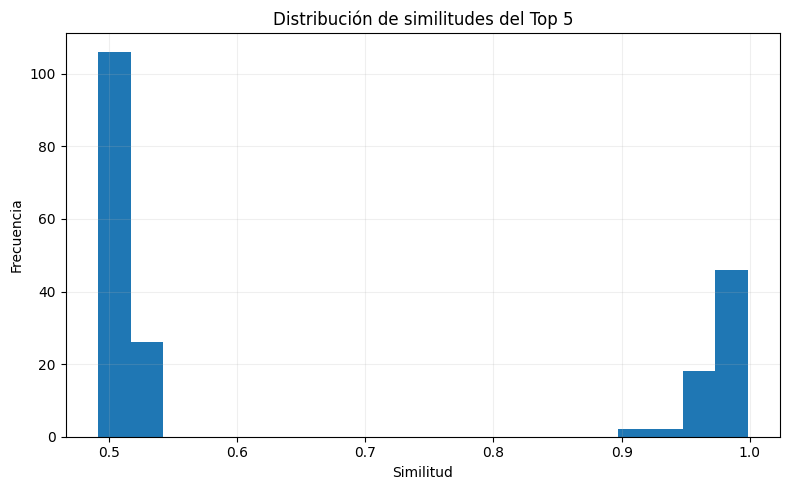

In [22]:
similitudes_top5 = []

for product_id, lista in rankings_prueba.items():
    origen_indice = ID_A_INDICE[product_id]

    for recomendado_id in lista:
        similitudes_top5.append(
            similitud_prueba[
                origen_indice,
                ID_A_INDICE[recomendado_id],
            ]
        )

similitudes_top5 = np.asarray(similitudes_top5, dtype=float)

percentiles_similitud = pd.DataFrame({
    "Percentil": [
        "Mínimo",
        "P25",
        "Mediana",
        "P75",
        "Máximo",
    ],
    "Similitud": [
        float(np.min(similitudes_top5)),
        float(np.quantile(similitudes_top5, 0.25)),
        float(np.median(similitudes_top5)),
        float(np.quantile(similitudes_top5, 0.75)),
        float(np.max(similitudes_top5)),
    ],
})

display(percentiles_similitud.round(4))

plt.figure(figsize=(8, 5))
plt.hist(
    similitudes_top5,
    bins=20,
)
plt.title("Distribución de similitudes del Top 5")
plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


La distribución permite distinguir recomendaciones con similitud alta, moderada o baja.

# 6. Despliegue

In [23]:
catalogo_final = construir_catalogo_para_corte(
    interacciones,
    configuracion_final["usa_comportamiento"],
)

encoder_final, scaler_final, matriz_final = ajustar_transformadores(
    catalogo_final,
    PESOS_FINALES,
)

similitud_final = cosine_similarity(matriz_final)
rankings_finales = construir_rankings(similitud_final, TOP_K)

filas_recomendaciones = []

for product_id in IDS_PRODUCTOS:
    origen_indice = ID_A_INDICE[product_id]

    for posicion, recomendado_id in enumerate(
        rankings_finales[product_id],
        start=1,
    ):
        recomendado_indice = ID_A_INDICE[recomendado_id]

        filas_recomendaciones.append({
            "source_product_id": product_id,
            "source_product_name": NOMBRE_POR_ID[product_id],
            "rank": posicion,
            "recommended_product_id": recomendado_id,
            "recommended_product_name": NOMBRE_POR_ID[recomendado_id],
            "similarity": similitud_final[
                origen_indice,
                recomendado_indice,
            ],
        })

recomendaciones_finales = pd.DataFrame(filas_recomendaciones)

print("Matriz de productos:", matriz_final.shape)
print("Matriz de similitud:", similitud_final.shape)
recomendaciones_finales.head(10)


Matriz de productos: (40, 17)
Matriz de similitud: (40, 40)


,source_product_id,source_product_name,rank,recommended_product_id,recommended_product_name,similarity
0,179,Silla de ruedas estándar,1,197,Silla de transporte ultraligera,0.9843
1,179,Silla de ruedas estándar,2,198,Silla de ruedas infantil,0.9776
2,179,Silla de ruedas estándar,3,180,Silla de ruedas reclinable,0.9735
3,179,Silla de ruedas estándar,4,191,Colchón antiescaras,0.5081
4,179,Silla de ruedas estándar,5,200,Andadera con asiento y ruedas,0.5077
5,180,Silla de ruedas reclinable,1,197,Silla de transporte ultraligera,0.9981
6,180,Silla de ruedas reclinable,2,198,Silla de ruedas infantil,0.9921
7,180,Silla de ruedas reclinable,3,179,Silla de ruedas estándar,0.9735
8,180,Silla de ruedas reclinable,4,184,Muletas axilares ajustables,0.5039
9,180,Silla de ruedas reclinable,5,209,Mesa puente para cama hospitalaria,0.5032


## 6.1 Guardado de artefactos

In [24]:
def convertir_json_seguro(valor):
    if isinstance(valor, dict):
        return {
            str(clave): convertir_json_seguro(contenido)
            for clave, contenido in valor.items()
        }

    if isinstance(valor, (list, tuple)):
        return [
            convertir_json_seguro(contenido)
            for contenido in valor
        ]

    if isinstance(valor, (np.integer, np.int64, np.int32)):
        return int(valor)

    if isinstance(valor, (np.floating, np.float64, np.float32, float)):
        return float(valor) if math.isfinite(float(valor)) else None

    if isinstance(valor, np.ndarray):
        return convertir_json_seguro(valor.tolist())

    if isinstance(valor, pd.Timestamp):
        return valor.isoformat()

    return valor


def escribir_json_estricto(
    ruta: Path,
    contenido,
) -> None:
    ruta.write_text(
        json.dumps(
            convertir_json_seguro(contenido),
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        ),
        encoding="utf-8",
    )


In [25]:
artefacto_joblib = {
    "encoder": encoder_final,
    "scaler": scaler_final,
    "weights": PESOS_FINALES,
    "categorical_columns": COLUMNAS_CATEGORICAS,
    "numeric_columns": COLUMNAS_NUMERICAS,
    "binary_column": COLUMNA_BINARIA,
    "product_ids": IDS_PRODUCTOS,
    "product_names": NOMBRE_POR_ID,
    "top_k": TOP_K,
}

ruta_joblib = carpeta_modelos / "recomendador_contenido.joblib"
ruta_json = carpeta_modelos / "recomendador_contenido.json"
ruta_matriz = carpeta_modelos / "matriz_productos.npy"
ruta_similitud = carpeta_modelos / "matriz_similitud.npy"
ruta_catalogo = carpeta_modelos / "catalogo_recomendacion.csv"
ruta_recomendaciones = carpeta_modelos / "recomendaciones_top5.csv"
ruta_indice = carpeta_modelos / "indice_productos.json"
ruta_metricas = carpeta_modelos / "metricas_recomendacion.json"
ruta_metadata = carpeta_modelos / "metadata_recomendacion.json"

joblib.dump(artefacto_joblib, ruta_joblib)
np.save(ruta_matriz, matriz_final)
np.save(ruta_similitud, similitud_final)
catalogo_final.to_csv(ruta_catalogo, index=False, encoding="utf-8")
recomendaciones_finales.to_csv(
    ruta_recomendaciones,
    index=False,
    encoding="utf-8",
)

indice_productos = {
    str(product_id): indice
    for indice, product_id in enumerate(IDS_PRODUCTOS)
}

escribir_json_estricto(ruta_indice, indice_productos)

metricas_json = {
    "selection_windows": tabla_ventanas.to_dict(orient="records"),
    "selection_average": (
        metricas_promedio_validacion.to_dict(orient="records")
    ),
    "selected_configuration": CONFIGURACION_SELECCIONADA,
    "final_test_month": str(VENTANA_PRUEBA),
    "final_test_cases": int(len(casos_prueba)),
    "content_model": metricas_prueba,
    "global_popularity_baseline": metricas_popularidad_global,
    "classification_popularity_baseline": metricas_popularidad_clase,
}

escribir_json_estricto(ruta_metricas, metricas_json)

json_portable = {
    "model_type": "content_based_cosine_similarity",
    "top_k": TOP_K,
    "product_ids": IDS_PRODUCTOS,
    "product_names": [
        NOMBRE_POR_ID[product_id]
        for product_id in IDS_PRODUCTOS
    ],
    "vectors": matriz_final.tolist(),
    "categorical_columns": COLUMNAS_CATEGORICAS,
    "categorical_categories": [
        categorias.tolist()
        for categorias in encoder_final.categories_
    ],
    "numeric_columns": COLUMNAS_NUMERICAS,
    "numeric_mean": scaler_final.mean_.tolist(),
    "numeric_scale": scaler_final.scale_.tolist(),
    "binary_column": COLUMNA_BINARIA,
    "weights": PESOS_FINALES,
}

escribir_json_estricto(ruta_json, json_portable)

metadata = {
    "name": "Recomendador de productos ortopédicos CEMYDI",
    "version": "1.0",
    "batch_name": BATCH_NAME,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "cutoff_date": str(interacciones["occurred_at"].max()),
    "technique": "Content-based recommendation with cosine similarity",
    "products": len(productos),
    "top_k": TOP_K,
    "features": {
        "categorical": COLUMNAS_CATEGORICAS,
        "numeric": COLUMNAS_NUMERICAS,
        "binary": COLUMNA_BINARIA,
    },
    "transformations": {
        "categorical": "OneHotEncoder",
        "numeric": "log1p + StandardScaler",
        "binary": "0/1",
    },
    "weights": PESOS_FINALES,
    "selected_configuration": CONFIGURACION_SELECCIONADA,
    "final_metrics": metricas_prueba,
    "temporal_limitation": (
        "Price and stock are current catalog values, "
        "not historical snapshots."
    ),
}

escribir_json_estricto(ruta_metadata, metadata)

print("Archivos generados:")
for ruta in [
    ruta_joblib,
    ruta_json,
    ruta_matriz,
    ruta_similitud,
    ruta_catalogo,
    ruta_recomendaciones,
    ruta_indice,
    ruta_metricas,
    ruta_metadata,
]:
    print("-", ruta)


Archivos generados:
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\recomendador_contenido.joblib
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\recomendador_contenido.json
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\matriz_productos.npy
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\matriz_similitud.npy
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\catalogo_recomendacion.csv
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Recomendacion_CRISP_DM\07_Modelos\recomendacion\recomendaciones_top5.csv
- C:\U

## 6.2 Verificación de los artefactos

In [26]:
artefacto_cargado = joblib.load(ruta_joblib)
matriz_cargada = np.load(ruta_matriz)
similitud_cargada = np.load(ruta_similitud)

rankings_cargados = construir_rankings(
    similitud_cargada,
    artefacto_cargado["top_k"],
)

assert np.allclose(matriz_final, matriz_cargada, atol=1e-12)
assert np.allclose(similitud_final, similitud_cargada, atol=1e-12)

for product_id in IDS_PRODUCTOS:
    assert rankings_finales[product_id] == rankings_cargados[product_id]

for ruta in [
    ruta_json,
    ruta_indice,
    ruta_metricas,
    ruta_metadata,
]:
    with ruta.open("r", encoding="utf-8") as archivo:
        json.load(archivo)

print(
    "Los artefactos cargados reproducen las matrices, "
    "similitudes y rankings."
)


Los artefactos cargados reproducen las matrices, similitudes y rankings.


## 6.3 Dos casos de inferencia

In [27]:
productos_prueba = productos["product_id"].astype(int).head(2)

pruebas_inferencia = []

for source_id in productos_prueba:
    origen_indice = ID_A_INDICE[source_id]

    for rank, recomendado_id in enumerate(
        rankings_cargados[source_id],
        start=1,
    ):
        recomendado = productos[
            productos["product_id"] == recomendado_id
        ].iloc[0]

        pruebas_inferencia.append({
            "Producto consultado": NOMBRE_POR_ID[source_id],
            "Posición": rank,
            "Recomendación": recomendado["product_name"],
            "Similitud": similitud_cargada[
                origen_indice,
                ID_A_INDICE[recomendado_id],
            ],
            "Clasificación": recomendado["classification"],
            "Tipo de adquisición": recomendado["acquisition_type"],
            "Stock": int(recomendado["stock"]),
        })

pd.DataFrame(pruebas_inferencia)


,Producto consultado,Posición,Recomendación,Similitud,Clasificación,Tipo de adquisición,Stock
0,Silla de ruedas estándar,1,Silla de transporte ultraligera,0.9843,Movilidad,MIXTO,46
1,Silla de ruedas estándar,2,Silla de ruedas infantil,0.9776,Movilidad,MIXTO,28
2,Silla de ruedas estándar,3,Silla de ruedas reclinable,0.9735,Movilidad,MIXTO,61
3,Silla de ruedas estándar,4,Colchón antiescaras,0.5081,Cuidado en cama,MIXTO,46
4,Silla de ruedas estándar,5,Andadera con asiento y ruedas,0.5077,Apoyo para caminar,MIXTO,47
5,Silla de ruedas reclinable,1,Silla de transporte ultraligera,0.9981,Movilidad,MIXTO,46
6,Silla de ruedas reclinable,2,Silla de ruedas infantil,0.9921,Movilidad,MIXTO,28
7,Silla de ruedas reclinable,3,Silla de ruedas estándar,0.9735,Movilidad,MIXTO,29
8,Silla de ruedas reclinable,4,Muletas axilares ajustables,0.5039,Apoyo para caminar,MIXTO,57
9,Silla de ruedas reclinable,5,Mesa puente para cama hospitalaria,0.5032,Cuidado en cama,MIXTO,38


Los resultados se calculan a partir del artefacto cargado y pueden compararse con `recomendaciones_top5.csv` y con la respuesta del backend.


# Conclusión breve

El recomendador utiliza los atributos del catálogo y las señales de vistas y búsquedas para generar cinco productos similares. La configuración final fue evaluada con ventanas temporales, líneas base y una prueba independiente de julio de 2026.